In [1]:
import os
import numpy as np
from lics_unwrap import *
from datetime import datetime

ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
ERROR 1: /opt/jaspy/lib/gdalplugins/.././libspatia

setting pyproj data directory


/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: undefined symbol: freexl_open_ods
/opt/jaspy/lib/gdalplugins/.././libspatialite.so.8: un

In [24]:
frame='050D_05246_131313'
imd_s='20241230'
cumfile_boi=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/sbois/post-3/{frame}/TS_GEOCml10mask/cum.h5'
cumfile_range=f'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic-upt-17052027/ranges/post-3/{frame}/TS_GEOCml10GACOSmask/cum_filt.h5'
cumfile=cumfile_range
cumh5 = h5.File(cumfile,'r')
imdates = cumh5['imdates'][()].astype(str).tolist()
cum = cumh5['cum']
n_im, length, width = cum.shape


def read_range(range_str, width, length):
    if re.match('[0-9]*:[0-9]*/[0-9]*:[0-9]', range_str):
        x1, x2, y1, y2 = [int(s) for s in re.split('[:/]', range_str)]
        if x2 == 0:
            x2 = width
        if y2 == 0:
            y2 = length
        if x1 > width-1 or x2 > width or y1 > length-1 or y2 > length:
            print("\nERROR:", file=sys.stderr)
            print("Index exceed input dimension ({0},{1})!".format(width,length), file=sys.stderr)
            return False
        if x1 >= x2 or y1 >= y2:
            print("\nERROR: x2/y2 must be larger than x1/y1", file=sys.stderr)
            return False
    else:
        print("\nERROR:", file=sys.stderr)
        print("Range format seems to be wrong (should be x1:x2/y1:y2)", file=sys.stderr)
        return False

    return [x1, x2, y1, y2]

### Reference area
refarea = []
refarea_geo = []
### Reference area
if refarea:
    if not tools_lib.read_range(refarea, width, length):
        print('\nERROR in {}\n'.format(refarea), file=sys.stderr)
    else:
        refx1, refx2, refy1, refy2 = tools_lib.read_range(refarea, width, length)
elif refarea_geo:
    lat1 = float(cumh5['corner_lat'][()])
    lon1 = float(cumh5['corner_lon'][()])
    dlat = float(cumh5['post_lat'][()])
    dlon = float(cumh5['post_lon'][()])
    if not tools_lib.read_range_geo(refarea_geo, width, length, lat1, dlat, lon1, dlon):
        print('\nERROR in {}\n'.format(refarea_geo), file=sys.stderr)
    else:
        refx1, refx2, refy1, refy2 = tools_lib.read_range_geo(refarea_geo, width, length, lat1, dlat, lon1, dlon)
else:
    refarea = cumh5['refarea'][()]
    if type(refarea) is bytes:
        refarea = refarea.decode('utf-8')
    refx1, refx2, refy1, refy2 = [int(s) for s in re.split('[:/]', refarea)]

#####

imd_m=''
maskfile=''
### Master (reference) date
if not imd_m:
    imd_m = imdates[0]

### mask
breakpoint()
if maskfile:
    mask = io_lib.read_img(maskfile, length, width)
    mask[mask==0] = np.nan
else:
    mask = np.ones((length, width), dtype=np.float32)

### Check date
if not imd_s in imdates:
    # print('\nERROR: No date of {} exist in {}, selecting nearest date'.format(imd_s, cumfile), file=sys.stderr)
    # return 2
    
    # Convert imd_s to datetime
    imd_s_dt = datetime.strptime(imd_s, "%Y%m%d")
    
    # Convert imdates to datetime list
    imdates_dt = [datetime.strptime(d, "%Y%m%d") for d in imdates]
    
    # Find the nearest date
    nearest_dt = min(imdates_dt, key=lambda d: abs(d - imd_s_dt))
    
    # Convert back to string
    imd_s = nearest_dt.strftime("%Y%m%d")
    
    print(f'\nWARNING: Date {imd_s_dt.strftime("%Y%m%d")} not found in {cumfile}, using nearest date {imd_s}', file=sys.stderr) 
 

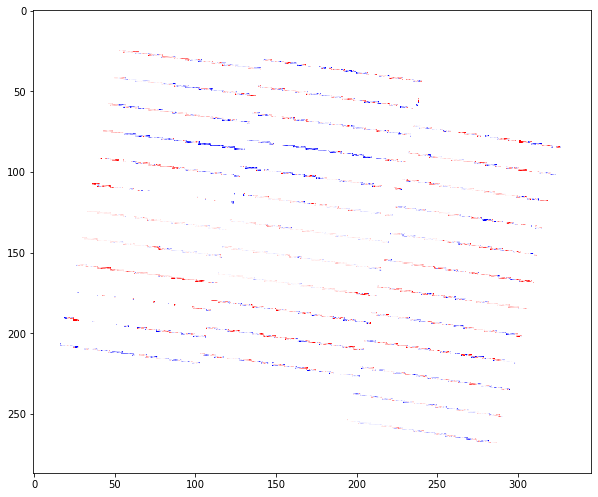

In [19]:
if not imd_m in imdates:
    print('\nERROR: No date of {} exist in {}!'.format(imd_m, cumfile), file=sys.stderr)

ix_s = imdates.index(imd_s)
ix_m = imdates.index(imd_m)



#%% Make flt
cum_s = cum[ix_s, :, :]
cum_m = cum[ix_m, :, :]

cum_dif = cum_s-cum_m
cum_dif = cum_dif-np.nanmean(cum_dif[refy1:refy2, refx1:refx2])
cum_dif = cum_dif*mask

# cum_dif.tofile(outfile)
plt.figure(figsize=(10,10))
plt.imshow(cum_dif, cmap='bwr', vmin=-100, vmax=100)


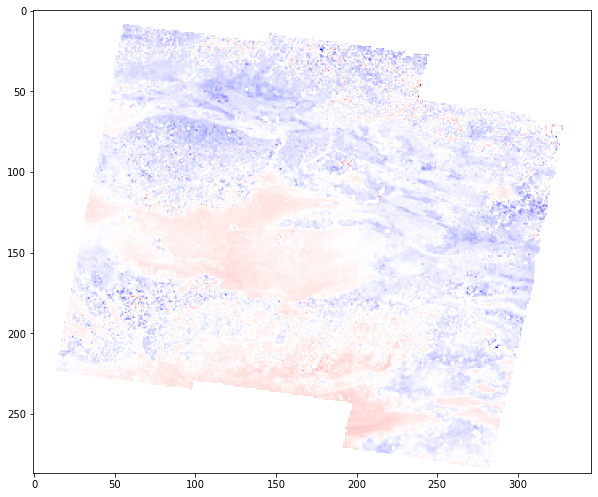

In [25]:
if not imd_m in imdates:
    print('\nERROR: No date of {} exist in {}!'.format(imd_m, cumfile), file=sys.stderr)

ix_s = imdates.index(imd_s)
ix_m = imdates.index(imd_m)



#%% Make flt
cum_s = cum[ix_s, :, :]
cum_m = cum[ix_m, :, :]

cum_dif = cum_s-cum_m
cum_dif = cum_dif-np.nanmean(cum_dif[refy1:refy2, refx1:refx2])
cum_dif = cum_dif*mask

# cum_dif.tofile(outfile)
plt.figure(figsize=(10,10))
plt.imshow(cum_dif, cmap='bwr', vmin=-100, vmax=100)
